In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import r2_score


from sklearn.cluster import KMeans

In [2]:
data = pd.read_csv(r'C:\Users\lenovo\Downloads\Sample - Superstore.csv.zip',encoding='ISO-8859-1')

## Explore Data

In [3]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Convert Data

In [7]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [9]:
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month

## Data Analyst

In [10]:
yearly_analysis = data.groupby('Year')[['Sales','Profit']].sum()
print(yearly_analysis)

            Sales      Profit
Year                         
2014  484247.4981  49543.9741
2015  470532.5090  61618.6037
2016  609205.5980  81795.1743
2017  733215.2552  93439.2696


In [11]:
sns.set_theme(style='whitegrid')

Text(0, 0.5, 'Total Profit ($)')

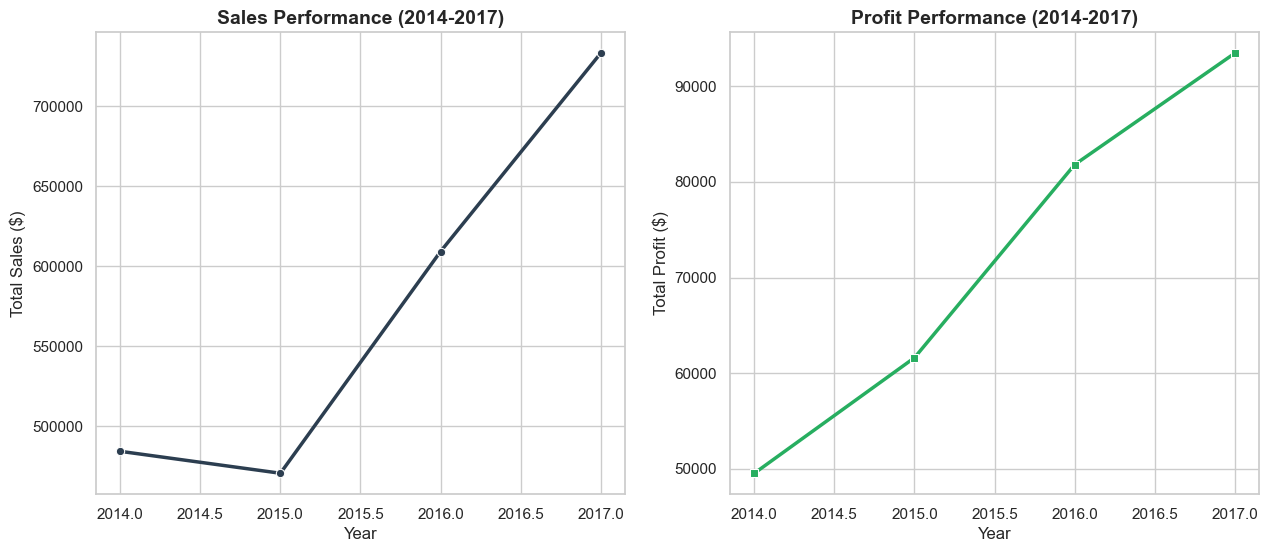

In [12]:
fig,ax = plt.subplots(1,2,figsize=(15,6))

sns.lineplot(x=yearly_analysis.index,y=yearly_analysis['Sales'],marker='o',ax=ax[0],color='#2c3e50',linewidth=2.5)
ax[0].set_title('Sales Performance (2014-2017)',fontsize=14,fontweight='bold')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Total Sales ($)')

sns.lineplot(x=yearly_analysis.index,y=yearly_analysis['Profit'],marker='s',ax=ax[1],color='#27ae60',linewidth=2.5)
ax[1].set_title('Profit Performance (2014-2017)',fontsize=14,fontweight='bold')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Total Profit ($)')

In [13]:
monthly_analysis = data.groupby('Month')[['Sales','Profit']].sum()
print(monthly_analysis)

             Sales      Profit
Month                         
1       94924.8356   9134.4461
2       59751.2514  10294.6107
3      205005.4888  28594.6872
4      137762.1286  11587.4363
5      155028.8117  22411.3078
6      152718.6793  21285.7954
7      147238.0970  13832.6648
8      159044.0630  21776.9384
9      307649.9457  36857.4753
10     200322.9847  31784.0413
11     352461.0710  35468.4265
12     325293.5035  43369.1919


In [18]:
monthly_analysis = data.groupby('Month')[['Sales','Profit']].sum()
monthly_analysis.index = [calendar.month_name[int(i)] for i in monthly_analysis.index]
months_order = [calendar.month_name[i] for i in range(1,13)]
monthly_analysis = monthly_analysis.reindex(months_order)

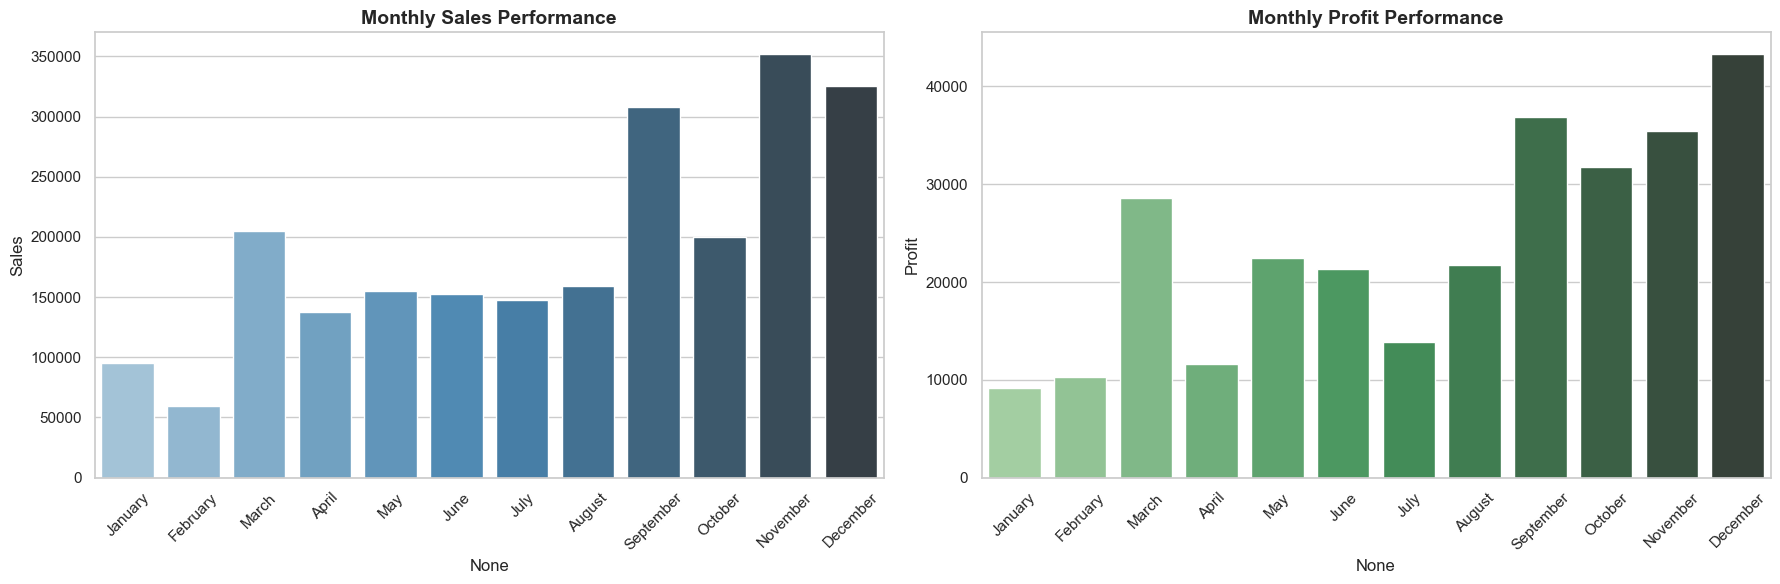

In [19]:
fig,ax = plt.subplots(1,2,figsize=(18,6))
sns.barplot(x=monthly_analysis.index,y=monthly_analysis['Sales'],ax=ax[0],hue=monthly_analysis.index,palette='Blues_d',legend=False)
ax[0].set_title('Monthly Sales Performance',fontsize=14,fontweight='bold')
ax[0].tick_params(axis='x',rotation=45)

sns.barplot(x=monthly_analysis.index,y=monthly_analysis['Profit'], ax=ax[1], hue=monthly_analysis.index,palette='Greens_d',legend=False)
ax[1].set_title('Monthly Profit Performance',fontsize=14,fontweight='bold')
ax[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

## Top 10 Customers

In [ ]:
customer_analysis = data.groupby(['Customer ID','Customer Name'])['Sales'].sum().sort_values(ascending=False).head(10)

In [ ]:
customer_analysis

In [ ]:
customer_analysis = customer_analysis.reset_index()

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data= customer_analysis,x='Sales',y='Customer Name',palette='viridis',hue='Customer Name')
plt.title('Top 10 Customers (Accurate analysis bu ID)',fontsize=15)
plt.show()

## Geoghraphic & Product Analyst

In [ ]:
region_analysis = data.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=region_analysis ,x='Region' ,y='Profit' ,hue='Region' ,palette='viridis' ,legend=False)
plt.title('Total Profit By Region',fontsize=15)
plt.show()

In [ ]:
sub_cat_analysis = data.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values(by='Sales',ascending=False).reset_index()

In [ ]:
sub_cat_analysis = sub_cat_analysis.melt(id_vars='Sub-Category',var_name='Metric',value_name='Amount')

In [ ]:
plt.figure(figsize=(15,7))
sns.barplot(data=sub_cat_analysis ,x='Sub-Category' ,y='Amount' ,hue='Metric' ,palette='muted')
plt.title('Sales vs Profit By Sub-Category ',fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()

## Customer Segmentation

In [ ]:
customer_features = data.groupby('Customer ID').agg({'Sales':'sum', 'Profit':'sum', 'Discount':'mean'}).reset_index()
customer_features.head()

In [ ]:
features = customer_features[['Sales','Profit','Discount']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
   

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method to find optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
customer_clusters = kmeans.fit_predict(scaled_features)

In [ ]:
customer_features['Cluster'] = customer_clusters
customer_features.head()

In [ ]:
cluster_analysis = customer_features.groupby('Cluster').agg({'Sales':'mean','Profit':'mean','Discount':'mean','Customer ID':'count'}).rename(columns={'Customer ID':'Customer_count'})
print(cluster_analysis)

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=customer_features,x='Sales',y='Profit',hue='Cluster',palette='viridis',s=100)
plt.axhline(0, color='red', linestyle='--')
plt.title('Customer Group Based on Sales and Profit')
plt.show()

## Prediction

In [ ]:
x = data[['Sales','Quantity','Discount']]
y = data['Profit']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(f'Training set Size:{x_train.shape[0]}')
print(f'Testing Set Size:{x_test.shape[0]}')

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
accuracy = r2_score(y_test,y_pred)
print(f'Model Accuracy (R2 score):{accuracy * 100:.2f}')

#### Random Forest Regressor

In [16]:
Q1 = data['Profit'].quantile(0.25)
Q3 = data['Profit'].quantile(0.75)
IQR = Q3-Q1

In [17]:
data_cleand = data[(data['Profit']>=Q1 -1.5*IQR)& (data['Profit'] <=Q3 + 1.5*IQR)]
print(f'Data Size befor :{len(data)}')
print(f'Data Size after cleaning :{len(data_cleand)}')

Data Size befor :9994
Data Size after cleaning :8113


In [ ]:
x = data_cleand[['Sales','Quantity','Discount']]
y = data_cleand['Profit']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rf_final = RandomForestRegressor(n_estimators=100,random_state=42)
rf_final.fit(x_train,y_train)
predictions = rf_final.predict(x_test)

In [ ]:
final_accuracy = r2_score(y_test,predictions)
print(f'Cleand Data Accuracy : {final_accuracy * 100 :.2f}%')

In [ ]:
data_advanced = pd.get_dummies(data_cleand[['Sales','Quantity','Discount','Category','Region','Profit']],drop_first=True)

In [ ]:
x=data_advanced.drop('Profit',axis=1)
y= data_advanced['Profit']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
final = RandomForestRegressor(n_estimators=100,max_depth=15,random_state=42)
final.fit(x_train,y_train)

In [ ]:
pre = final.predict(x_test)
print(f'New Accuracy : {r2_score(y_test,pre)  * 100 :.2f}%')

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(x_train, y_train)

In [ ]:
predictions = xgb_model.predict(x_test)

In [ ]:
print(f'New Accuracy : {r2_score(y_test,predictions)  * 100 :.2f}%')

In [ ]:
data_final = data_cleand.copy()
data_final.loc[:, 'Ship Days'] = (data_final['Ship Date'] -data_final['Order Date']).dt.days

In [ ]:
data_final.loc[:, 'Order_Month'] = data_final['Order Date'].dt.month

In [ ]:
sub_cat_profit = data_final.groupby('Sub-Category')['Profit'].transform('mean')
data_final.loc[:, 'Sub_Cat_Avg_Profit'] = sub_cat_profit

In [ ]:
features = ['Sales','Quantity','Discount','Ship Days','Order_Month','Sub_Cat_Avg_Profit']
x= data_final[features]
y= data_final['Profit']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
final_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=7, subsample=0.8, colsample_bytree=0.8,random_state=42)
final_xgb.fit(x_train, y_train)

In [ ]:
predictions = final_xgb.predict(x_test)

In [ ]:
print(f'New Accuracy : {r2_score(y_test,predictions)  * 100 :.2f}%')

# Executive Summary & Recommendations
### 1.Profitability Issue in 'Tables' Category

    •	Observation: The 'Tables' sub-category shows high sales volume but consistently generates negative profit(loser)
    •	Analysis:This deficit suggests that the cost of good sold(COGS),shipping expenses, or aggressive discounting strategies are                           outweighing the revenue generated from this category.
    •	Recommendation: Management should immediately review the pricing strategy for tables.Reducing discounts or renegotiating                               shipping contracts for bulky items could help mitigate these losses.
    
###  2.Seasonal Sales Trends
    •	Observation: There is a significant spike in both Sales and profit during the fourth quarter(Q4),specifically in November and                          December.
    •	Analysis: This trend aligns with the holiday season and end-of-year promotions.
    •	Recommendation: Optimize inventory levels and increase staffing during Q4 to handle the surge in demand and maximize potential                         revenue.
    
### 3.Top Performing Customers
    •	Observation :A small group of 'Platinum' customers(e.g.,Sean Miller, Tamara Chand) contributes a disproportionately large share of total               revenue.
    •	Recommendation :Implement a loyalty program or personalized marketing campaigns for these high-value customers to ensure retention and long-         term partnership.
    
### 4.Regional Performance
    •	Observation :Profit distribution varies significantly across regions ,with some regions showing much higher efficiency than others.
    •	Recommendation : Conduct a deep dive into the 'West' and 'East' regions(the most profitable) to replicable their success strategies in                 lower-performing regions.


# Model Performance & Technical Conclusion
* **Best Model:** After testing multiple algorithms (Linear Regression, Random Forest, and XGBoost), the **XGBoost Regressor** achieved the highest                     accuracy.
* **Final Accuracy:** The model reached **73.02%** , demonstrating strong predictive power.
* **Key Improvements:** Accuracy was significantly improved by:
        1. **Data Cleaning:** Removing outliers that were distorting the profit patterns.
        2. **Feature Engineering:** Adding categorical data (Sub-Category, Region) and time-based features (Ship Days).
* **Business Impact:** This model can used to forecast potential profit for upcoming orders, allowing the business to adjust discount strategies and                          avoid low-margin transactions.